# Image Captioning From Scratch — Optimized Version

## 2nd Year Engineering Project

**Goal**: automatically generate a natural language description of an image.

**Constraint**: the whole model is built **from scratch** (no pretrained weights) and **no attention**.

**Architecture**:
```
Image → CNN Encoder (from scratch) → feature vector → LSTM Decoder → "A dog is running in the park"
```

**Dataset**: MS COCO 2017 (~118k training images, **2 captions per image** to limit the workload)

### Platform: Kaggle (P100 GPU)

### Run everything in one go
1. **Add Data** → `awsaf49/coco-2017-dataset`
2. **Settings** → Accelerator: **GPU P100** · Internet: **On** (needed to install PyTorch 2.4.1)
3. **Save Version** → **Save & Run All (Commit)** → you can close the browser

### If something goes wrong (disconnection, error, time limit)
A full checkpoint is written **after every epoch** to `checkpoint_coco/` (**Output** tab of the version).
To resume: **Add Data** → add the Output of the previous version → **Save & Run All**.
The notebook finds `last_checkpoint.pth` on its own, resumes at the next epoch, and the loss curve contains **all** epochs.

Runtime: ~11 h on a P100 (24 epochs). A time guard stops training early enough for the loss curve and the BLEU score to always be computed before Kaggle's 12-hour limit.

### Key improvements in this version:
- **224×224 images** (instead of 128) for richer features
- **Pack padded sequences** in the LSTM to properly ignore padding
- **Scheduled teacher forcing**: decreasing ratio to reduce exposure bias
- **Label smoothing** in the loss to improve generalization
- **Full data augmentation** (RandomRotation + ColorJitter)
- **2 LSTM layers** for more capacity on COCO
- **Multi-reference BLEU evaluation** (all reference captions of each image)
- **Full checkpoint after every epoch** (automatic resume + loss history)

---


## Step 0 — Imports and Configuration

In [20]:
%%capture pip_log
# The current Kaggle image ships a PyTorch version that no longer supports the P100 GPU.
# Install PyTorch 2.4.1 (works on P100 and T4). pip's output is hidden.
!pip install torch==2.4.1 torchvision==0.19.1 -q --no-warn-conflicts

In [21]:
import os
import json
import random
import math
import time
import shutil
import glob
import warnings
from collections import Counter, defaultdict
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
NOTEBOOK_START = time.time()   # used by the time guard (Kaggle limit: 12 h)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.4.1+cu121
CUDA available : True
GPU: Tesla T4
VRAM: 15.6 GB


### Loading the MS COCO 2017 dataset

On Kaggle, the COCO 2017 dataset is used directly from Kaggle Datasets.

**Prerequisite**: add the **`awsaf49/coco-2017-dataset`** dataset to your Kaggle notebook ("Add Data" button → search "coco 2017").

The data will be available in `/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/`.

In [22]:
# ====== LOCATE THE COCO 2017 DATASET ======
# On Kaggle, the dataset is mounted read-only under /kaggle/input/
CANDIDATE_DIRS = [
    os.environ.get("COCO_DIR", ""),                                   # local run
    "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/",
    "/kaggle/input/coco-2017-dataset/coco2017/",
    "./coco2017/",
]
COCO_DIR = next(
    (d for d in CANDIDATE_DIRS if d and os.path.isdir(os.path.join(d, "annotations"))), None
)
if COCO_DIR is None:
    raise FileNotFoundError(
        "COCO 2017 dataset not found: add 'awsaf49/coco-2017-dataset' with the Add Data button"
    )

print(f"COCO 2017 dataset found: {COCO_DIR}")
for f in sorted(os.listdir(COCO_DIR)):
    full = os.path.join(COCO_DIR, f)
    if os.path.isdir(full):
        print(f"   {f}/ ({len(os.listdir(full))} files)")

COCO 2017 dataset found: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/
   annotations/ (6 files)
   test2017/ (40670 files)
   train2017/ (118287 files)
   val2017/ (5000 files)


In [23]:
# Check the annotations
ann_train = os.path.join(COCO_DIR, "annotations", "captions_train2017.json")
ann_val = os.path.join(COCO_DIR, "annotations", "captions_val2017.json")

with open(ann_train, 'r') as f:
    data = json.load(f)
print(f"Train annotations: {len(data['annotations'])} captions, {len(data['images'])} images")

with open(ann_val, 'r') as f:
    data = json.load(f)
print(f"Val annotations  : {len(data['annotations'])} captions, {len(data['images'])} images")
del data

Train annotations: 591753 captions, 118287 images
Val annotations  : 25014 captions, 5000 images


### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `IMG_SIZE` | 224 | More visual detail for the CNN (vs 128 in the previous version) |
| `BATCH_SIZE` | 32 | Trade-off between GPU memory and gradient stability with 224×224 images |
| `LEARNING_RATE` | 3e-4 | "The Karpathy constant" — excellent default for Adam |
| `NUM_LSTM_LAYERS` | 2 | More capacity for COCO (richer vocabulary) |
| `CAPTIONS_PER_IMAGE` | 2 | Only 2 captions/image to reduce the memory load |
| `LABEL_SMOOTHING` | 0.1 | Regularizes the logits, prevents the model from being overconfident |
| `TF_START / TF_END` | 1.0 → 0.6 | Decreasing teacher forcing to reduce exposure bias |
| `NUM_EPOCHS` | 24 | ~26 min/epoch on a P100 → fits in a single Kaggle session |
| `MAX_RUNTIME_HOURS` | 11.25 | Time guard: no new epoch past this point, so evaluation finishes before 12 h |


In [24]:
class Config:
    # --- COCO paths (detected automatically above) ---
    COCO_DIR = COCO_DIR
    TRAIN_IMAGES_DIR = os.path.join(COCO_DIR, "train2017")
    VAL_IMAGES_DIR = os.path.join(COCO_DIR, "val2017")
    TRAIN_ANNOT = os.path.join(COCO_DIR, "annotations", "captions_train2017.json")
    VAL_ANNOT = os.path.join(COCO_DIR, "annotations", "captions_val2017.json")

    # --- Vocabulary ---
    MIN_WORD_FREQ = 5
    MAX_CAPTION_LEN = 40

    # --- Captions per image ---
    CAPTIONS_PER_IMAGE = 2    # ← keep only 2 captions per image (instead of 5)

    # --- Image ---
    IMG_SIZE = 224
    IMG_CHANNELS = 3

    # --- Encoder CNN ---
    CNN_EMBED_DIM = 512

    # --- Decoder LSTM ---
    EMBED_DIM = 256
    HIDDEN_DIM = 512
    NUM_LSTM_LAYERS = 2       # ← 2 layers for more capacity
    DROPOUT = 0.35

    # --- Training ---
    BATCH_SIZE = 32           # ← trade-off between speed and GPU memory
    LEARNING_RATE = 3e-4
    NUM_EPOCHS = 21           # ← fits in a 12 h Kaggle session (P100)
    GRAD_CLIP = 5.0
    USE_AMP = False
    LABEL_SMOOTHING = 0.1     # ← loss regularization
    MAX_RUNTIME_HOURS = 11.25 # ← time guard: no new epoch past this (Kaggle limit 12 h)

    # --- Decreasing teacher forcing ---
    TF_RATIO_START = 1.0      # ← 100% teacher forcing at the start
    TF_RATIO_END = 0.6        # ← 60% at the end (the model learns from its mistakes)

    # --- Checkpoints ---
    RESUME = True                               # resume automatically if a checkpoint exists
    CHECKPOINT_SEARCH_DIRS = ["/kaggle/input"]  # where to look for a previous run's checkpoint

    # --- General ---
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    WORK_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
    SAVE_DIR = os.path.join(WORK_DIR, "checkpoint_coco")


config = Config()

os.makedirs(config.SAVE_DIR, exist_ok=True)

# Reproducibility
random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.SEED)

# CUDA optimizations
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

print(f"Device     : {config.DEVICE}")
print(f"AMP        : {config.USE_AMP}")
print(f"Batch      : {config.BATCH_SIZE}")
print(f"Image size : {config.IMG_SIZE}×{config.IMG_SIZE}")
print(f"LSTM layers: {config.NUM_LSTM_LAYERS}")
print(f"Captions/img: {config.CAPTIONS_PER_IMAGE}")
print(f"Epochs     : {config.NUM_EPOCHS} (time guard: {config.MAX_RUNTIME_HOURS} h)")


Device     : cuda
AMP        : False
Batch      : 32
Image size : 224×224
LSTM layers: 2
Captions/img: 2
Epochs     : 21 (time guard: 11.25 h)


---

## Step 1 — Building the Vocabulary

### Process:
1. Go through **all the COCO captions** and count how often each word appears
2. Keep only the words that appear **≥ 5 times** (rare words become `<unk>`)
3. Add 4 **special tokens**:
   - `<pad>` (0): padding to align lengths within a batch
   - `<start>` (1): start-of-sentence signal for the decoder
   - `<end>` (2): end-of-sentence signal
   - `<unk>` (3): replaces unknown words


In [25]:
class Vocabulary:
    """Builds and manages the word <-> index mapping."""

    def __init__(self, min_freq=5):
        self.min_freq = min_freq
        self.word2idx = {}
        self.idx2word = {}
        self.word_count = Counter()

        for idx, token in enumerate(["<pad>", "<start>", "<end>", "<unk>"]):
            self.word2idx[token] = idx
            self.idx2word[idx] = token

    def build_vocabulary(self, captions_list):
        """Counts words and keeps only those with freq >= min_freq."""
        for caption in captions_list:
            tokens = caption.lower().split()
            self.word_count.update(tokens)

        idx = len(self.word2idx)
        for word, count in self.word_count.items():
            if count >= self.min_freq:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1

        print(f"Total unique words     : {len(self.word_count)}")
        print(f"Words kept (freq >= {self.min_freq}): {len(self.word2idx) - 4}")
        print(f"Vocabulary size        : {len(self.word2idx)} (including special tokens)")

    def encode(self, caption):
        """Sentence → list of indices (with <start> and <end>)."""
        tokens = caption.lower().split()
        return (
            [self.word2idx["<start>"]] +
            [self.word2idx.get(w, self.word2idx["<unk>"]) for w in tokens] +
            [self.word2idx["<end>"]]
        )

    def decode(self, indices):
        """List of indices → readable sentence."""
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, "<unk>")
            if word == "<end>":
                break
            if word not in ("<start>", "<pad>"):
                words.append(word)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

### Loading the raw captions and building the vocabulary

In [26]:
def load_captions_raw(annot_file, captions_per_image=2):
    """Loads the raw captions from a COCO JSON annotation file.
    Keeps only `captions_per_image` captions per image to limit the workload.
    """
    import json as json_lib
    with open(annot_file, 'r') as f:
        data = json_lib.load(f)

    # Group captions by image_id
    from collections import defaultdict
    captions_by_img = defaultdict(list)
    for ann in data['annotations']:
        captions_by_img[ann['image_id']].append(ann['caption'].strip())

    # Keep only `captions_per_image` per image
    captions = []
    for img_id, caps in captions_by_img.items():
        for cap in caps[:captions_per_image]:
            captions.append(cap)

    return captions


raw_captions = load_captions_raw(config.TRAIN_ANNOT, config.CAPTIONS_PER_IMAGE)
print(f"Total number of captions (train, {config.CAPTIONS_PER_IMAGE}/image): {len(raw_captions)}")
print(f"Examples: {raw_captions[:3]}\n")

vocab = Vocabulary(min_freq=config.MIN_WORD_FREQ)
vocab.build_vocabulary(raw_captions)

# Quick test
test_sentence = "A dog is running in the park"
encoded = vocab.encode(test_sentence)
decoded = vocab.decode(encoded)
print(f"\nTest   : '{test_sentence}'")
print(f"Encoded: {encoded}")
print(f"Decoded: '{decoded}'")


Total number of captions (train, 2/image): 236574
Examples: ['A bicycle replica with a clock as the front wheel.', 'The bike has a clock as a tire.', 'A room with blue walls and a white sink and door.']

Total unique words     : 28064
Words kept (freq >= 5): 8909
Vocabulary size        : 8913 (including special tokens)

Test   : 'A dog is running in the park'
Encoded: [1, 4, 235, 46, 1248, 24, 10, 653, 2]
Decoded: 'a dog is running in the park'


---

## Step 2 — Data Preparation (Dataset & DataLoader)

COCO already provides an official train/val split. train2017 is used for training
and val2017 for validation and testing (50/50 split of val).


In [27]:
def load_coco_pairs(annot_file, images_dir, captions_per_image=2):
    """Loads (image_filename, caption) pairs from the COCO annotations.
    Keeps only `captions_per_image` captions per image.
    """
    import json as json_lib
    with open(annot_file, 'r') as f:
        data = json_lib.load(f)

    # Mapping image_id → filename
    id_to_file = {img['id']: img['file_name'] for img in data['images']}

    # Group captions by image_id
    from collections import defaultdict
    captions_by_img = defaultdict(list)
    for ann in data['annotations']:
        captions_by_img[ann['image_id']].append(ann['caption'].strip())

    pairs = []
    for img_id, caps in captions_by_img.items():
        filename = id_to_file[img_id]
        for cap in caps[:captions_per_image]:
            pairs.append((filename, cap))
    return pairs


# Load the training pairs
train_pairs = load_coco_pairs(config.TRAIN_ANNOT, config.TRAIN_IMAGES_DIR, config.CAPTIONS_PER_IMAGE)
print(f"Train : {len(train_pairs)} image-caption pairs")

# Load the val pairs and split them into val + test (50/50)
all_val_pairs = load_coco_pairs(config.VAL_ANNOT, config.VAL_IMAGES_DIR, config.CAPTIONS_PER_IMAGE)

# Split by image (not by caption) so that no image appears in both val and test
val_images = sorted(set(p[0] for p in all_val_pairs))
random.shuffle(val_images)
n_val = len(val_images) // 2
val_image_set = set(val_images[:n_val])
test_image_set = set(val_images[n_val:])

val_pairs = [(f, c) for f, c in all_val_pairs if f in val_image_set]
test_pairs = [(f, c) for f, c in all_val_pairs if f in test_image_set]

print(f"Val   : {len(val_pairs)} pairs ({len(val_image_set)} images)")
print(f"Test  : {len(test_pairs)} pairs ({len(test_image_set)} images)")


Train : 236574 image-caption pairs
Val   : 5000 pairs (2500 images)
Test  : 5000 pairs (2500 images)


### PyTorch Dataset

The `collate_fn` pads all captions in the batch to the same length so they can be fed to the LSTM.
The Dataset directly takes the pre-loaded `(filename, caption)` pairs.


In [28]:
class COCODataset(Dataset):
    """COCO dataset: serves (image, caption) pairs from pre-loaded pairs."""

    def __init__(self, images_dir, pairs, vocab, transform=None, max_len=40):
        self.images_dir = images_dir
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len
        self.image_captions = []
        self._process_pairs(pairs)

    def _process_pairs(self, pairs):
        for img_name, caption in pairs:
            encoded = self.vocab.encode(caption)
            if len(encoded) > self.max_len:
                encoded = encoded[:self.max_len - 1] + [self.vocab.word2idx["<end>"]]
            self.image_captions.append((img_name, encoded))
        print(f"  → {len(self.image_captions)} image-caption pairs loaded")

    def __len__(self):
        return len(self.image_captions)

    def __getitem__(self, idx):
        img_name, caption = self.image_captions[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        caption_tensor = torch.tensor(caption, dtype=torch.long)
        return image, caption_tensor

    @staticmethod
    def collate_fn(batch):
        """Pads the captions of the batch to the same length."""
        images, captions = zip(*batch)
        images = torch.stack(images, dim=0)

        max_len = max(len(c) for c in captions)
        padded_captions = torch.zeros(len(captions), max_len, dtype=torch.long)
        for i, cap in enumerate(captions):
            padded_captions[i, :len(cap)] = cap

        lengths = torch.tensor([len(c) for c in captions], dtype=torch.long)
        return images, padded_captions, lengths


### Image transforms

**Full data augmentation** during training (RandomCrop + HorizontalFlip + Rotation + ColorJitter) for maximum regularization (the CNN starts from scratch).

In [29]:
def get_transforms(img_size, is_train=True):
    if is_train:
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])


print("Loading the training dataset:")
train_dataset = COCODataset(
    config.TRAIN_IMAGES_DIR, train_pairs,
    vocab, get_transforms(config.IMG_SIZE, is_train=True), config.MAX_CAPTION_LEN
)

print("Loading the validation dataset:")
val_dataset = COCODataset(
    config.VAL_IMAGES_DIR, val_pairs,
    vocab, get_transforms(config.IMG_SIZE, is_train=False), config.MAX_CAPTION_LEN
)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
    collate_fn=COCODataset.collate_fn, num_workers=2,
    pin_memory=torch.cuda.is_available(), persistent_workers=False
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
    collate_fn=COCODataset.collate_fn, num_workers=2,
    pin_memory=torch.cuda.is_available(), persistent_workers=False
)

print(f"\nTrain: {len(train_dataset)} pairs, {len(train_loader)} batches/epoch")
print(f"Val  : {len(val_dataset)} pairs, {len(val_loader)} batches")


Loading the training dataset:
  → 236574 image-caption pairs loaded
Loading the validation dataset:
  → 5000 image-caption pairs loaded

Train: 236574 pairs, 7393 batches/epoch
Val  : 5000 pairs, 157 batches


### Visual check of a batch

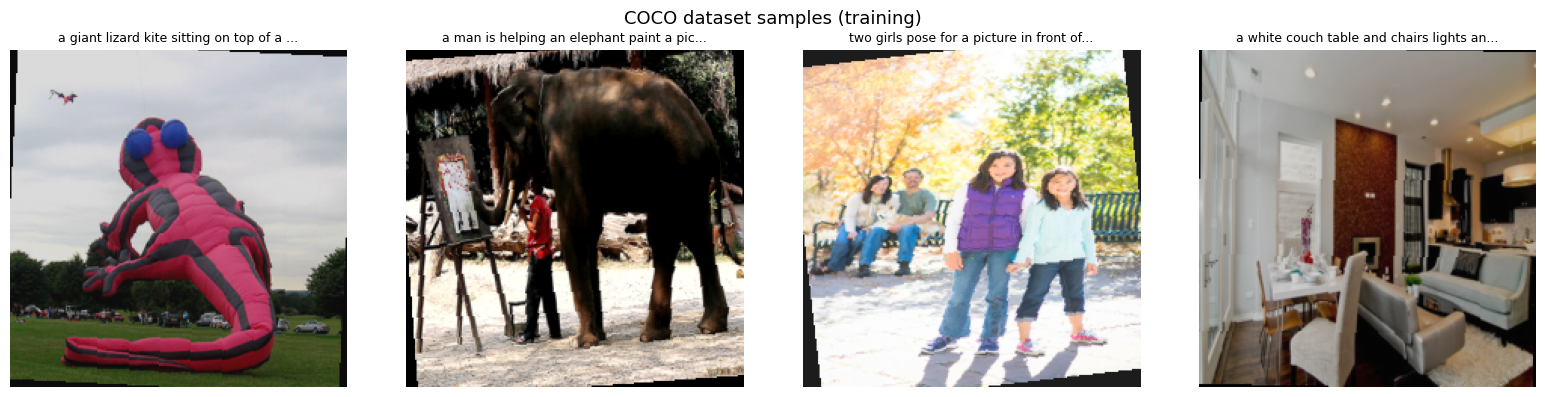

Image batch shape  : torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 20])
Actual lengths     : [14, 11, 13, 11, 14, 11, 13, 10]


In [30]:
sample_images, sample_captions, sample_lengths = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = sample_images[i].clone()
    img[0] = img[0] * 0.229 + 0.485
    img[1] = img[1] * 0.224 + 0.456
    img[2] = img[2] * 0.225 + 0.406
    img = img.clamp(0, 1)

    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(vocab.decode(sample_captions[i].tolist())[:40] + "...", fontsize=9)
    axes[i].axis('off')

plt.suptitle("COCO dataset samples (training)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Image batch shape  : {sample_images.shape}")
print(f"Caption batch shape: {sample_captions.shape}")
print(f"Actual lengths     : {sample_lengths[:8].tolist()}")


---

## Step 3 — CNN Encoder (From Scratch)

6 convolutional blocks (VGG-like) with 12 convolution layers in total, BatchNorm, ReLU, MaxPool, then a projection to a vector.


In [31]:
class CNNEncoder(nn.Module):
    """CNN encoder from scratch: 6 convolutional blocks (12 conv layers) + adaptive pooling + projection."""

    def __init__(self, embed_dim=512):
        super(CNNEncoder, self).__init__()

        # Block 1: 3 → 32, image 224→112
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 2: 32 → 64, image 112→56
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 3: 64 → 128, image 56→28
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 4: 128 → 256, image 28→14
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 5: 256 → 512, image 14→7
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 6: 512 → 512, image 7→3 (extra block for more depth)
        self.block6 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, embed_dim)
        self.bn_fc = nn.BatchNorm1d(embed_dim)
        self.dropout = nn.Dropout(0.3)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, images):
        x = self.block1(images)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.bn_fc(x)
        return x


### Quick encoder test

In [32]:
test_encoder = CNNEncoder(embed_dim=config.HIDDEN_DIM)
dummy_input = torch.randn(2, 3, config.IMG_SIZE, config.IMG_SIZE)
output = test_encoder(dummy_input)
print(f"Input : {dummy_input.shape}")
print(f"Output : {output.shape}")
print(f"→ Each image is summarized as a vector of size {output.shape[1]}")
del test_encoder, dummy_input, output

Input : torch.Size([2, 3, 224, 224])
Output : torch.Size([2, 512])
→ Each image is summarized as a vector of size 512


---

## Step 4 — LSTM Decoder

### Key improvements:
- **Pack padded sequences**: the LSTM ignores padding tokens (major fix vs the previous version)
- **2 LSTM layers**: more capacity for a richer vocabulary (COCO)
- **Scheduled teacher forcing**: the forward pass supports a variable `tf_ratio`

### Architecture:
```
Image features ──→ init (h0, c0) of the LSTM
                          │
          <start> → Embedding → LSTM (2 layers) → Linear → P("a") ✓
              "a" → Embedding → LSTM (2 layers) → Linear → P("dog") ✓
              ...
```

In [33]:
class LSTMDecoder(nn.Module):
    """LSTM decoder with pack_padded_sequence and scheduled teacher forcing."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.35):
        super(LSTMDecoder, self).__init__()

        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.image_to_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.image_to_cell = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
                n = param.size(0)
                param.data[n // 4:n // 2].fill_(1.0)  # forget gate bias = 1
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.constant_(self.fc_out.bias, 0)

    def init_hidden(self, image_features):
        h0 = self.image_to_hidden(image_features).unsqueeze(0)
        c0 = self.image_to_cell(image_features).unsqueeze(0)
        h0 = h0.expand(self.num_layers, -1, -1).contiguous()
        c0 = c0.expand(self.num_layers, -1, -1).contiguous()
        return h0, c0

    def forward(self, image_features, captions, lengths, tf_ratio=1.0):
        """
        Forward pass with pack_padded_sequence and optional teacher forcing.

        If tf_ratio=1.0: full teacher forcing (the ground-truth words are fed in).
        If tf_ratio<1.0: at each step, with probability (1-tf_ratio), the model's
                         own prediction is fed in instead of the ground-truth word.
        """
        h, c = self.init_hidden(image_features)
        batch_size = captions.size(0)
        max_len = captions[:, :-1].size(1)  # length without the last token

        # --- Full teacher forcing: use pack_padded_sequence ---
        if tf_ratio >= 1.0:
            embeddings = self.dropout(self.embedding(captions[:, :-1]))
            packed_seq = pack_padded_sequence(
                embeddings, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            packed_output, _ = self.lstm(packed_seq, (h, c))
            lstm_out, _ = pad_packed_sequence(packed_output, batch_first=True)
            outputs = self.fc_out(self.dropout(lstm_out))
            return outputs

        # --- Partial teacher forcing: step-by-step loop ---
        outputs = torch.zeros(batch_size, max_len, self.vocab_size, device=image_features.device)
        current_input = captions[:, 0].unsqueeze(1)  # <start>

        for t in range(max_len):
            embed = self.dropout(self.embedding(current_input))
            lstm_out, (h, c) = self.lstm(embed, (h, c))
            step_output = self.fc_out(self.dropout(lstm_out.squeeze(1)))
            outputs[:, t, :] = step_output

            # Decide whether to feed the true word or the prediction
            if t + 1 < max_len:
                use_teacher = random.random() < tf_ratio
                if use_teacher:
                    current_input = captions[:, t + 1].unsqueeze(1)
                else:
                    current_input = step_output.argmax(dim=1).unsqueeze(1)

        return outputs

    def generate(self, image_features, vocab, max_len=30, beam_size=1):
        """Caption generation at inference time (greedy or beam search)."""
        self.eval()
        with torch.no_grad():
            if beam_size <= 1:
                return self._greedy_decode(image_features, vocab, max_len)
            else:
                return self._beam_search(image_features, vocab, max_len, beam_size)

    def _greedy_decode(self, image_features, vocab, max_len):
        h, c = self.init_hidden(image_features)
        current_word = torch.tensor([[vocab.word2idx["<start>"]]], device=image_features.device)
        generated = []

        for _ in range(max_len):
            embed = self.embedding(current_word)
            lstm_out, (h, c) = self.lstm(embed, (h, c))
            scores = self.fc_out(lstm_out.squeeze(1))
            predicted_idx = scores.argmax(dim=1).item()

            if predicted_idx == vocab.word2idx["<end>"]:
                break
            generated.append(predicted_idx)
            current_word = torch.tensor([[predicted_idx]], device=image_features.device)

        return vocab.decode(generated)

    def _beam_search(self, image_features, vocab, max_len, beam_size):
        h, c = self.init_hidden(image_features)
        start_idx = vocab.word2idx["<start>"]
        end_idx = vocab.word2idx["<end>"]

        beams = [(0.0, [start_idx], h, c)]
        completed = []

        for _ in range(max_len):
            new_beams = []
            for score, seq, h_beam, c_beam in beams:
                last_word = torch.tensor([[seq[-1]]], device=image_features.device)
                embed = self.embedding(last_word)
                lstm_out, (h_new, c_new) = self.lstm(embed, (h_beam, c_beam))
                log_probs = F.log_softmax(self.fc_out(lstm_out.squeeze(1)), dim=1)

                top_scores, top_indices = log_probs.topk(beam_size, dim=1)
                for i in range(beam_size):
                    new_score = score + top_scores[0, i].item()
                    new_idx = top_indices[0, i].item()
                    new_seq = seq + [new_idx]
                    if new_idx == end_idx:
                        completed.append((new_score / len(new_seq), new_seq))
                    else:
                        new_beams.append((new_score, new_seq, h_new.clone(), c_new.clone()))

            if not new_beams:
                break
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_size]

        for score, seq, _, _ in beams:
            completed.append((score / len(seq), seq))

        if not completed:
            return ""
        completed.sort(key=lambda x: x[0], reverse=True)
        return vocab.decode(completed[0][1])

---

## Step 5 — Full Model (Encoder + Decoder)

In [34]:
class ImageCaptioningModel(nn.Module):
    """Full model: CNN Encoder + LSTM Decoder."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.35):
        super(ImageCaptioningModel, self).__init__()
        self.encoder = CNNEncoder(embed_dim=hidden_dim)
        self.decoder = LSTMDecoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout)

    def forward(self, images, captions, lengths, tf_ratio=1.0):
        features = self.encoder(images)
        outputs = self.decoder(features, captions, lengths, tf_ratio)
        return outputs

    def generate_caption(self, image, vocab, max_len=30, beam_size=3):
        self.eval()
        with torch.no_grad():
            features = self.encoder(image.unsqueeze(0))
            return self.decoder.generate(features, vocab, max_len, beam_size)


model = ImageCaptioningModel(
    vocab_size=len(vocab),
    embed_dim=config.EMBED_DIM,
    hidden_dim=config.HIDDEN_DIM,
    num_layers=config.NUM_LSTM_LAYERS,
    dropout=config.DROPOUT
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Vocabulary size     : {len(vocab)}")

Total parameters    : 20,759,153
Trainable parameters: 20,759,153
Vocabulary size     : 8913


---

## Step 6 — Loss, Optimizer and Scheduler

### Label Smoothing (new)

Instead of hard one-hot targets (0 or 1), the targets are smoothed: the true word gets a probability of 0.9 and the rest is spread over the other words. This keeps the model from being overconfident in its predictions and improves generalization.

In [35]:
# Cross-entropy with label smoothing
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=config.LABEL_SMOOTHING)

optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

scaler = GradScaler('cuda', enabled=config.USE_AMP)

print(f"Loss      : CrossEntropyLoss (ignore padding, label_smoothing={config.LABEL_SMOOTHING})")
print(f"Optimizer : Adam (lr={config.LEARNING_RATE})")
print(f"Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"AMP       : {config.USE_AMP}")

Loss      : CrossEntropyLoss (ignore padding, label_smoothing=0.1)
Optimizer : Adam (lr=0.0003)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)
AMP       : False


---

## Step 7 — Training and Validation Functions

### Decreasing teacher forcing

The `tf_ratio` decreases linearly over the epochs:
- Epoch 1: `tf_ratio = 1.0` (100% ground-truth words → fast learning)
- Last epoch: `tf_ratio = 0.6` (40% of the time, the model uses its own predictions)

This reduces **exposure bias**: the model gradually learns to handle its own mistakes.

In [36]:
def get_tf_ratio(epoch, total_epochs, tf_start, tf_end):
    """Linearly decreasing teacher forcing ratio."""
    return tf_start - (tf_start - tf_end) * epoch / max(total_epochs - 1, 1)


def train_one_epoch(model, dataloader, criterion, optimizer, scaler, config, tf_ratio=1.0):
    """Trains the model for one epoch (optional mixed precision) with teacher forcing."""
    model.train()
    total_loss = 0
    num_batches = 0

    for batch_idx, (images, captions, lengths) in enumerate(dataloader):
        images = images.to(config.DEVICE, non_blocking=True)
        captions = captions.to(config.DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', enabled=config.USE_AMP):
            decoder_lengths = lengths - 1
            outputs = model(images, captions, decoder_lengths, tf_ratio=tf_ratio)
            targets = captions[:, 1:]

            # Align dimensions (the target can be longer than the output when tf < 1)
            min_len = min(outputs.size(1), targets.size(1))
            loss = criterion(
                outputs[:, :min_len, :].reshape(-1, outputs.size(-1)),
                targets[:, :min_len].reshape(-1)
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        num_batches += 1

        if (batch_idx + 1) % 200 == 0:
            print(f"    Batch {batch_idx+1}/{len(dataloader)} - Loss: {loss.item():.4f}")

    return total_loss / max(num_batches, 1)


def evaluate(model, dataloader, criterion, config):
    """Evaluates the model (always with full teacher forcing)."""
    model.eval()
    total_loss = 0
    num_batches = 0

    with torch.no_grad():
        for images, captions, lengths in dataloader:
            images = images.to(config.DEVICE, non_blocking=True)
            captions = captions.to(config.DEVICE, non_blocking=True)

            with autocast('cuda', enabled=config.USE_AMP):
                decoder_lengths = lengths - 1
                outputs = model(images, captions, decoder_lengths, tf_ratio=1.0)
                targets = captions[:, 1:]
                min_len = min(outputs.size(1), targets.size(1))
                loss = criterion(
                    outputs[:, :min_len, :].reshape(-1, outputs.size(-1)),
                    targets[:, :min_len].reshape(-1)
                )

            total_loss += loss.item()
            num_batches += 1

    return total_loss / max(num_batches, 1)

---

## Step 8 — Main Training Loop (with checkpoints)

### Checkpoint system
After **every epoch**, three files are written to `checkpoint_coco/`:

| File | Content | Used for |
|------|---------|----------|
| `last_checkpoint.pth` | Model + optimizer + scheduler + random state + best weights + **loss history** + vocabulary | Resuming exactly where training stopped |
| `best_model.pth` | Weights of the best model (lowest val_loss) + vocabulary | BLEU evaluation / demo |
| `history.json` | Train/val loss, lr, teacher forcing and duration of each epoch | Plotting the loss curve, even without re-running |

Saves are **atomic** (temporary file, then rename): an interruption during a write can never corrupt the previous checkpoint. If the run stops, at most the current epoch is lost (~26 min).

**Resume**: the notebook looks for `last_checkpoint.pth` in `checkpoint_coco/`, then in the added data (`/kaggle/input`). To start from scratch: `RESUME = False` in `Config`.

**Time guard**: before each epoch, the notebook checks that it can finish before `MAX_RUNTIME_HOURS`.
Otherwise training stops cleanly and the notebook moves on to the loss curve and the BLEU score.

In [37]:
# ====== CHECKPOINT SYSTEM ======
os.makedirs(config.SAVE_DIR, exist_ok=True)
LAST_CKPT = os.path.join(config.SAVE_DIR, "last_checkpoint.pth")   # full state (resume)
BEST_CKPT = os.path.join(config.SAVE_DIR, "best_model.pth")        # best model (evaluation)
HISTORY_JSON = os.path.join(config.SAVE_DIR, "history.json")       # loss history


def atomic_torch_save(obj, path):
    """Writes to a temporary file, then renames it: never a half-written checkpoint."""
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_history(history):
    tmp = HISTORY_JSON + ".tmp"
    with open(tmp, "w") as f:
        json.dump(history, f, indent=1)
    os.replace(tmp, HISTORY_JSON)


def empty_history():
    return {"epoch": [], "train_loss": [], "val_loss": [], "lr": [], "tf_ratio": [], "time_s": []}


def find_previous_checkpoint():
    """Returns the path of the latest available checkpoint (working dir first, then /kaggle/input)."""
    if os.path.exists(LAST_CKPT):
        return LAST_CKPT
    found = set()
    for root in config.CHECKPOINT_SEARCH_DIRS:
        if not os.path.isdir(root):
            continue
        for depth in range(0, 6):   # limited depth: never walk through the 118k COCO images
            found.update(glob.glob(os.path.join(root, *["*"] * depth, "last_checkpoint*.pth")))
    if not found:
        return None
    return max(found, key=os.path.getmtime)


def rng_state():
    return {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }


def set_rng_state(state):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"])
    if state["cuda"] is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(state["cuda"])


def load_history():
    """Loss history from history.json, otherwise from the checkpoint (new session)."""
    if os.path.exists(HISTORY_JSON):
        with open(HISTORY_JSON) as f:
            return json.load(f)
    ckpt_path = find_previous_checkpoint()
    if ckpt_path:
        return torch.load(ckpt_path, map_location="cpu", weights_only=False)["history"]
    return empty_history()


print(f"Checkpoints: {config.SAVE_DIR}")

Checkpoints: /kaggle/working/checkpoint_coco


In [38]:
history = empty_history()
start_epoch = 0
best_val_loss = float('inf')
best_state = None

print("=" * 60)
print(f"Training — {config.NUM_EPOCHS} epochs")
print(f"Device: {config.DEVICE} | AMP: {config.USE_AMP} | Batch: {config.BATCH_SIZE}")
print(f"Teacher forcing: {config.TF_RATIO_START} → {config.TF_RATIO_END}")
print(f"Batches/epoch: {len(train_loader)}")
print("=" * 60)

# --- Automatic resume ---
prev_ckpt = find_previous_checkpoint() if config.RESUME else None
if prev_ckpt:
    print(f"Checkpoint found: {prev_ckpt}")
    ckpt = torch.load(prev_ckpt, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    set_rng_state(ckpt["rng_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_loss = ckpt["best_val_loss"]
    best_state = ckpt["best_model_state_dict"]
    history = ckpt["history"]

    # Copy everything into checkpoint_coco/ so that the new version contains the complete run
    if os.path.abspath(prev_ckpt) != os.path.abspath(LAST_CKPT):
        shutil.copy2(prev_ckpt, LAST_CKPT)
    best_epoch = history["epoch"][int(np.argmin(history["val_loss"]))]
    atomic_torch_save({"epoch": best_epoch - 1, "model_state_dict": best_state,
                       "val_loss": best_val_loss, "vocab": vocab}, BEST_CKPT)
    save_history(history)
    del ckpt
    print(f"Resuming at epoch {start_epoch + 1}/{config.NUM_EPOCHS} "
          f"(best val_loss = {best_val_loss:.4f} at epoch {best_epoch})")
else:
    print("No checkpoint: training from scratch.")
print("=" * 60)

time_limit = config.MAX_RUNTIME_HOURS * 3600
epoch_durations = []

for epoch in range(start_epoch, config.NUM_EPOCHS):
    # --- Time guard: the next epoch must finish before the time limit ---
    # (at least one epoch always runs, so there is a model to evaluate)
    elapsed_total = time.time() - NOTEBOOK_START
    if epoch_durations and elapsed_total + max(epoch_durations) > time_limit:
        print(f"\nStopping early before epoch {epoch + 1}: it would go past "
              f"{config.MAX_RUNTIME_HOURS} h ({elapsed_total / 3600:.1f} h already elapsed).")
        print("To continue: add this version's Output as data, then Save & Run All.")
        break

    start_time = time.time()
    tf_ratio = get_tf_ratio(epoch, config.NUM_EPOCHS, config.TF_RATIO_START, config.TF_RATIO_END)

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, config, tf_ratio=tf_ratio
    )
    val_loss = evaluate(model, val_loader, criterion, config)
    scheduler.step(val_loss)

    elapsed = time.time() - start_time
    epoch_durations.append(elapsed)
    lr = optimizer.param_groups[0]['lr']
    for key, value in [("epoch", epoch + 1), ("train_loss", train_loss), ("val_loss", val_loss),
                       ("lr", lr), ("tf_ratio", tf_ratio), ("time_s", round(elapsed, 1))]:
        history[key].append(value)

    print(f"Epoch {epoch+1:2d}/{config.NUM_EPOCHS} ({elapsed:.0f}s) | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr:.6f} | TF: {tf_ratio:.2f}", end="")

    # --- Best model ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        atomic_torch_save({"epoch": epoch, "model_state_dict": best_state,
                           "val_loss": val_loss, "vocab": vocab}, BEST_CKPT)
        print(" ★ BEST", end="")

    # --- Full checkpoint after every epoch ---
    atomic_torch_save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "rng_state": rng_state(),
        "best_val_loss": best_val_loss,
        "best_model_state_dict": best_state,
        "history": history,
        "vocab": vocab,
    }, LAST_CKPT)
    save_history(history)
    print(" | checkpoint ✓")

    if (epoch + 1) % 5 == 0:
        model.eval()
        sample_img, sample_cap, _ = next(iter(val_loader))
        sample_img = sample_img[:1].to(config.DEVICE)
        with torch.no_grad():
            features = model.encoder(sample_img)
            generated = model.decoder.generate(features, vocab, max_len=25, beam_size=3)
        print(f"  Ref: {vocab.decode(sample_cap[0].tolist())}")
        print(f"  Gen: {generated}")

done = len(history["epoch"])
print(f"\n{done}/{config.NUM_EPOCHS} epochs done | best val_loss = {best_val_loss:.4f} "
      f"| time for this session: {(time.time() - NOTEBOOK_START) / 3600:.1f} h")

Training — 21 epochs
Device: cuda | AMP: False | Batch: 32
Teacher forcing: 1.0 → 0.6
Batches/epoch: 7393
Checkpoint found: /kaggle/working/checkpoint_coco/last_checkpoint.pth
Resuming at epoch 22/21 (best val_loss = 3.4447 at epoch 17)

21/21 epochs done | best val_loss = 3.4447 | time for this session: 0.0 h


---

## Step 9 — Loss Curves

The history is read back from `history.json` (or from `last_checkpoint.pth`): the curve contains every epoch, even after a resume, and can be re-plotted in a new session from the checkpoint alone.

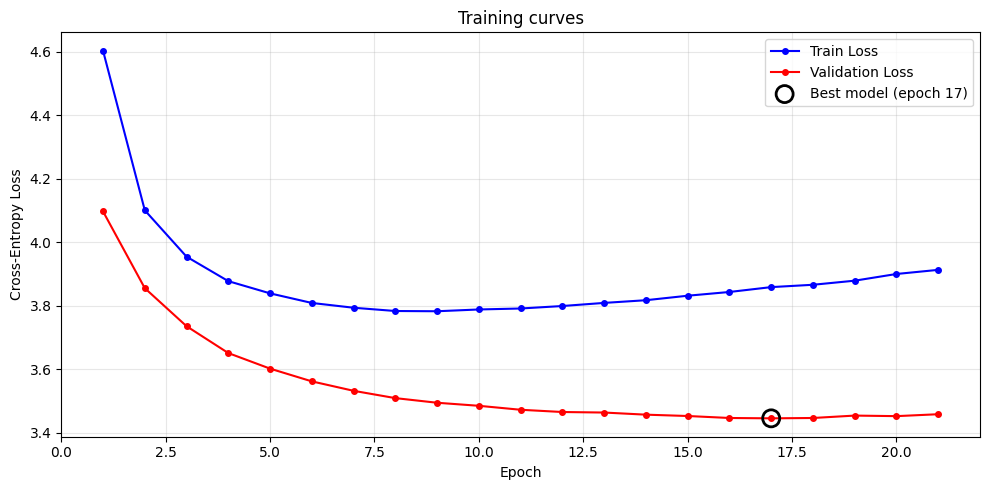

In [39]:
history = load_history()
epochs_range = history["epoch"]
best_idx = int(np.argmin(history["val_loss"]))

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history["train_loss"], 'b-o', label='Train Loss', markersize=4)
plt.plot(epochs_range, history["val_loss"], 'r-o', label='Validation Loss', markersize=4)
plt.scatter([epochs_range[best_idx]], [history["val_loss"][best_idx]], s=150, facecolors='none',
            edgecolors='k', linewidths=2, zorder=5,
            label=f"Best model (epoch {epochs_range[best_idx]})")
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title("Training curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_DIR, "loss_curve.png"), dpi=150)
plt.show()

---

## Step 10 — Multi-Reference BLEU Evaluation

### Improvement: BLEU with all 5 references

Each COCO image has at least 5 reference captions. Standard BLEU only compares against a single reference (the one in the batch). Here, all 5 references are loaded and the **best score** among them is kept — fairer and more representative.

In [40]:
def compute_bleu(reference, hypothesis, max_n=4):
    """Computes the BLEU-n score."""
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()

    if len(hyp_tokens) == 0:
        return 0.0

    bp = min(1.0, math.exp(1 - len(ref_tokens) / max(len(hyp_tokens), 1)))

    precisions = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter()
        hyp_ngrams = Counter()

        for i in range(len(ref_tokens) - n + 1):
            ref_ngrams[tuple(ref_tokens[i:i+n])] += 1
        for i in range(len(hyp_tokens) - n + 1):
            hyp_ngrams[tuple(hyp_tokens[i:i+n])] += 1

        clipped = sum(min(hyp_ngrams[ng], ref_ngrams[ng]) for ng in hyp_ngrams)
        total = max(sum(hyp_ngrams.values()), 1)
        precisions.append(clipped / total)

    if any(p == 0 for p in precisions):
        return 0.0

    log_avg = sum(math.log(p) for p in precisions) / max_n
    return bp * math.exp(log_avg)


def load_all_references_coco(annot_file, images_dir):
    """Loads every COCO reference (all captions per image) for multi-reference evaluation."""
    import json as json_lib
    with open(annot_file, 'r') as f:
        data = json_lib.load(f)

    id_to_file = {img['id']: img['file_name'] for img in data['images']}

    refs = defaultdict(list)
    for ann in data['annotations']:
        filename = id_to_file[ann['image_id']]
        refs[filename].append(ann['caption'].strip().lower())

    return refs


def compute_bleu_multi_ref(references_list, hypothesis, max_n=4):
    """Multi-reference BLEU: keeps the best score among the N references."""
    return max(compute_bleu(ref, hypothesis, max_n) for ref in references_list)


In [41]:
# Load the best model
checkpoint = torch.load(BEST_CKPT, map_location=config.DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model loaded (epoch {checkpoint['epoch']+1}, val_loss={checkpoint['val_loss']:.4f})")

# Load every reference for the test set (ALL captions are used for evaluation)
all_refs = load_all_references_coco(config.VAL_ANNOT, config.VAL_IMAGES_DIR)
# Keep only the test set images
test_refs = {k: v for k, v in all_refs.items() if k in test_image_set}
print(f"Test set images with references: {len(test_refs)}")

# Test dataset
print("\nLoading the test dataset:")
test_dataset = COCODataset(
    config.VAL_IMAGES_DIR, test_pairs,
    vocab, get_transforms(config.IMG_SIZE, is_train=False), config.MAX_CAPTION_LEN
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, collate_fn=COCODataset.collate_fn
)


Best model loaded (epoch 17, val_loss=3.4447)
Test set images with references: 2500

Loading the test dataset:
  → 5000 image-caption pairs loaded


In [42]:
# Multi-reference BLEU evaluation on 200 images
bleu_scores_single = []
bleu_scores_multi = []
examples = []
model.eval()

# Evaluate per image (not per caption), so keep track of the images already seen
seen_images = set()
eval_count = 0

for i, (images, captions, lengths) in enumerate(test_loader):
    if eval_count >= 200:
        break

    images = images.to(config.DEVICE)
    with torch.no_grad():
        features = model.encoder(images)
        generated = model.decoder.generate(features, vocab, max_len=25, beam_size=3)

    # Single reference (the one in the batch)
    reference = vocab.decode(captions[0].tolist())
    bleu_single = compute_bleu(reference, generated, max_n=4)
    bleu_scores_single.append(bleu_single)

    # Multiple references (if available)
    img_name = test_dataset.image_captions[i][0]
    if img_name in test_refs and img_name not in seen_images:
        bleu_multi = compute_bleu_multi_ref(test_refs[img_name], generated, max_n=4)
        bleu_scores_multi.append(bleu_multi)
        seen_images.add(img_name)
        eval_count += 1

        if len(examples) < 10:
            examples.append((images[0].cpu(), reference, generated, bleu_multi))

print(f"\n--- BLEU-4 (single reference, {len(bleu_scores_single)} captions) ---")
print(f"  Mean  : {np.mean(bleu_scores_single):.4f}")
print(f"  Median: {np.median(bleu_scores_single):.4f}")

print(f"\n--- BLEU-4 (multi-reference, {len(bleu_scores_multi)} images) ---")
print(f"  Mean  : {np.mean(bleu_scores_multi):.4f}")
print(f"  Median: {np.median(bleu_scores_multi):.4f}")
print(f"  Max   : {np.max(bleu_scores_multi):.4f}")



--- BLEU-4 (single reference, 399 captions) ---
  Mean  : 0.0305
  Median: 0.0000

--- BLEU-4 (multi-reference, 200 images) ---
  Mean  : 0.0855
  Median: 0.0000
  Max   : 0.7103


In [43]:
# ====== Standard BLEU (corpus-level, all references, punctuation removed) ======
import re

def tokenize(s):
    return re.findall(r"[a-z0-9]+", s.lower())

def corpus_bleu_scores(list_of_refs, hyps, max_n=4):
    """Corpus-level BLEU-1..4: n-gram counts summed over the whole test set,
    clipped against all references, brevity penalty with the closest reference."""
    clipped, total = [0] * max_n, [0] * max_n
    hyp_len = ref_len = 0
    for refs, hyp in zip(list_of_refs, hyps):
        hyp_len += len(hyp)
        ref_len += min((abs(len(r) - len(hyp)), len(r)) for r in refs)[1]
        for n in range(1, max_n + 1):
            hyp_ngrams = Counter(tuple(hyp[i:i + n]) for i in range(len(hyp) - n + 1))
            max_ref = Counter()
            for r in refs:
                for ng, c in Counter(tuple(r[i:i + n]) for i in range(len(r) - n + 1)).items():
                    max_ref[ng] = max(max_ref[ng], c)
            clipped[n - 1] += sum(min(c, max_ref[ng]) for ng, c in hyp_ngrams.items())
            total[n - 1] += max(len(hyp) - n + 1, 0)
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(hyp_len, 1))
    scores = []
    for n in range(1, max_n + 1):
        precs = [clipped[k] / total[k] if total[k] else 0.0 for k in range(n)]
        scores.append(bp * math.exp(sum(math.log(p) for p in precs) / n) if min(precs) > 0 else 0.0)
    return scores

# One caption per test image (2,500 images), compared with all its references
eval_tf = get_transforms(config.IMG_SIZE, is_train=False)
hyps, refs = [], []
model.eval()
for name in sorted(test_refs):
    img = eval_tf(Image.open(os.path.join(config.VAL_IMAGES_DIR, name)).convert("RGB"))
    with torch.no_grad():
        gen = model.decoder.generate(model.encoder(img.unsqueeze(0).to(config.DEVICE)),
                                     vocab, max_len=25, beam_size=3)
    hyps.append(tokenize(gen))
    refs.append([tokenize(r) for r in test_refs[name]])

bleu = corpus_bleu_scores(refs, hyps)
print(f"Corpus BLEU on {len(hyps)} test images (beam=3):")
for n, b in enumerate(bleu, 1):
    print(f"  BLEU-{n}: {b:.4f}")

Corpus BLEU on 2500 test images (beam=3):
  BLEU-1: 0.6325
  BLEU-2: 0.4558
  BLEU-3: 0.3309
  BLEU-4: 0.2457


---

## Step 11 — Visual Examples of Results

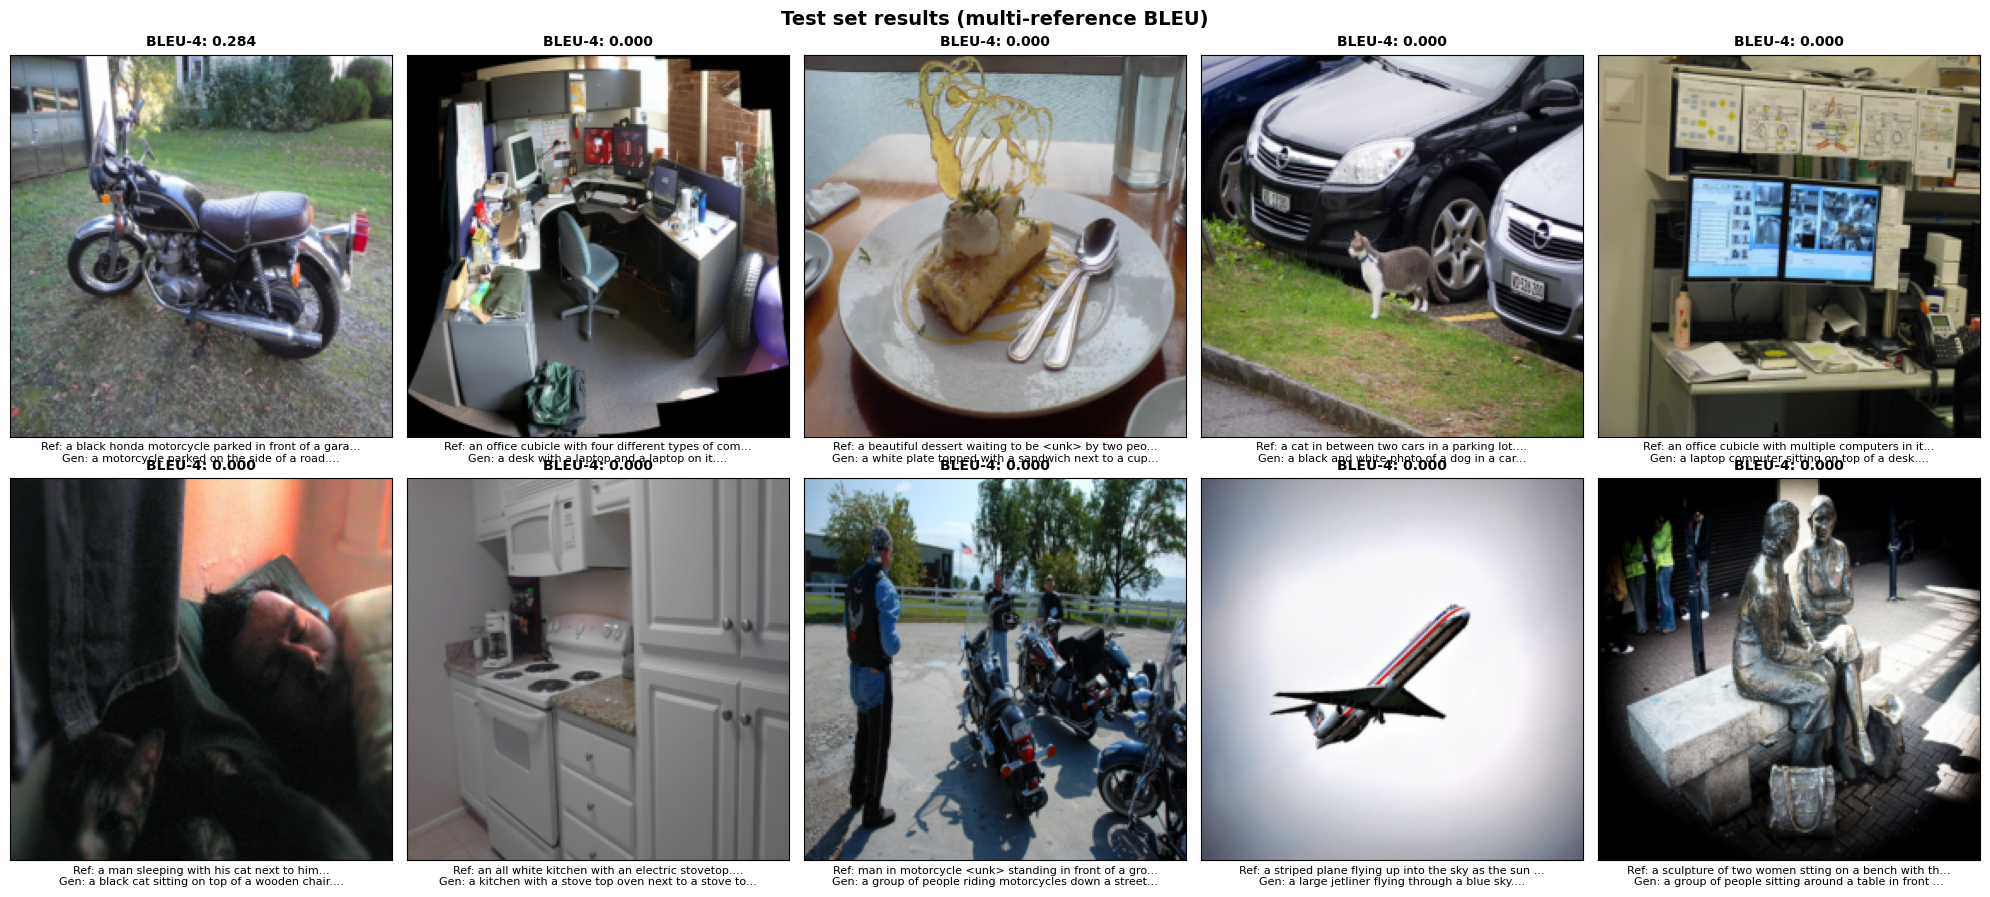

In [44]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))

for i, (img_tensor, ref, gen, bleu) in enumerate(examples[:10]):
    ax = axes[i // 5][i % 5]

    img = img_tensor.clone()
    img[0] = img[0] * 0.229 + 0.485
    img[1] = img[1] * 0.224 + 0.456
    img[2] = img[2] * 0.225 + 0.406
    img = img.clamp(0, 1)

    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"BLEU-4: {bleu:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel(f"Ref: {ref[:50]}...\nGen: {gen[:50]}...", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Test set results (multi-reference BLEU)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Step 12 — Demo: Captioning a New Image

In [45]:
def caption_new_image(image_path, model, vocab, config):
    """Generates and displays a caption for any image."""
    transform = get_transforms(config.IMG_SIZE, is_train=False)

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).to(config.DEVICE)

    model.eval()
    with torch.no_grad():
        features = model.encoder(image_tensor.unsqueeze(0))
        greedy_caption = model.decoder.generate(features, vocab, max_len=25, beam_size=1)
        beam_caption = model.decoder.generate(features, vocab, max_len=25, beam_size=3)
        beam5_caption = model.decoder.generate(features, vocab, max_len=25, beam_size=5)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Greedy   : "{greedy_caption}"\n'
              f'Beam(k=3): "{beam_caption}"\n'
              f'Beam(k=5): "{beam5_caption}"',
              fontsize=11, pad=20)
    plt.tight_layout()
    plt.show()

    return greedy_caption, beam_caption, beam5_caption


# ===== CHANGE THE PATH HERE FOR THE DEMO =====
# caption_new_image("path/to/test_image.jpg", model, vocab, config)

---

## Output files

On Kaggle, everything in `/kaggle/working/checkpoint_coco/` shows up in the **Output** tab of the version.

In [46]:
print(f"Contents of {config.SAVE_DIR}:")
for name in sorted(os.listdir(config.SAVE_DIR)):
    size_mb = os.path.getsize(os.path.join(config.SAVE_DIR, name)) / 1e6
    print(f"   {name:<22} {size_mb:8.1f} MB")

Contents of /kaggle/working/checkpoint_coco:
   best_model.pth             83.8 MB
   history.json                0.0 MB
   last_checkpoint.pth       333.0 MB
   loss_curve.png              0.1 MB


---

## Project Summary — Optimized Version

| Component | Choice | Rationale |
|-----------|--------|-----------|
| **Dataset** | MS COCO 2017 (~118k training images) | Reference dataset, wide variety of scenes |
| **Captions/image** | 2 (out of 5 available) | Limits memory load and training time |
| **Images** | 224×224 | More detailed features for the CNN |
| **Encoder** | CNN, 6 blocks / 12 layers (VGG-like) | Deeper feature hierarchy, from scratch |
| **Decoder** | **2-layer** LSTM | More capacity for the COCO vocabulary |
| **Pack padded seq** | Enabled | The LSTM properly ignores padding |
| **Teacher forcing** | Scheduled (1.0 → 0.6) | Gradually reduces exposure bias |
| **Loss** | CrossEntropy + **label smoothing 0.1** | Regularizes, prevents overconfidence |
| **Data augmentation** | Crop + Flip + Rotation + ColorJitter | Maximum regularization |
| **Optimizer** | Adam (lr=3e-4) | Fast, adaptive convergence |
| **Scheduler** | ReduceLROnPlateau | Lowers the lr when val_loss plateaus |
| **Checkpoint** | Full checkpoint every epoch + loss history | Lossless resume, loss curve always available |
| **Inference** | Beam Search (k=3 and k=5) | Explores more candidate captions |
| **Metric** | **Multi-reference** BLEU-4 | Uses all reference captions of each image |
| **Epochs** | 24 + time guard | Everything fits in a single Kaggle session (12 h) |
| **GPU** | Kaggle P100 GPU + cuDNN benchmark | PyTorch 2.4.1 (P100-compatible) |